In [13]:
import sys
sys.path.append('../src/')
import os
import copy

import numpy as np
import sklearn
from sklearn import metrics
import tensorly as tn
import math
import matlab.engine
import matplotlib.pyplot as plt
import time


import ll1_tools

## Load data and loewnerize (300 node layer)

In [17]:
targets_path = '../data/L300100_data/targets.npy'
targets = np.load(targets_path)
print(f"Targets shape: {targets.shape}")

inputs_path = '../data/L300100_data/99/layers.layer_0.linear.npy'
inputs_raw = np.load(inputs_path)
print(f"Inputs shape: {inputs_raw.shape}")

outputs_path = '../data/L300100_data/99/layers.layer_0.rat.npy'
outputs_raw = np.load(outputs_path)
print(f"Outputs shape: {outputs_raw.shape}")

# tensorlab_path = '~/ware/matlab_tools/tensorlab'
tensorlab_path = '~/tools/matlab_tools/Tensorlab'

num_sets = 10
tic = time.perf_counter()
lwn_tns_raw, obs, obs_trgts = ll1_tools.split_data(inputs_raw, outputs_raw, targets, tensorlab_path, num_sets)
toc = time.perf_counter()
print(toc-tic)

Targets shape: (9984,)
Inputs shape: (39, 256, 300)
Outputs shape: (39, 256, 300)
557.7998692159963


## remove inf values from lwn_tns: 
Rationale: if numerator of the lowner matrix entry is zero, so would be the numerator, hence replacing inf with zero is justified

In [18]:
lwn_tns = lwn_tns_raw
for t in lwn_tns:
    t[np.isinf(t)] = 0

## perform decompositions for all lwn_tns

In [19]:
eng = matlab.engine.start_matlab()
s = eng.genpath(tensorlab_path)
eng.addpath(s, nargout=0)

num_terms = 250
rat_deg = 3

L = rat_deg * np.ones(num_terms)
mdls = list()
outs = list()

tic = time.perf_counter()
for tns in lwn_tns:
    U, out = eng.ll1(tns, L, nargout=2)
    mdls.append(U)
    outs.append(out)
toc = time.perf_counter()
print(toc-tic)

6939.115337602998


## check model fits

[0.770049974583847, 0.7686491153725387, 0.7662816646714441, 0.7658307077942049, 0.7679719472269341, 0.7743977260063969, 0.7695798308906366, 0.7777908340243807, 0.7712599242551869, 0.7692009049830074]


Text(0.5, 1.0, '(L,L,1) model Fit Scores')

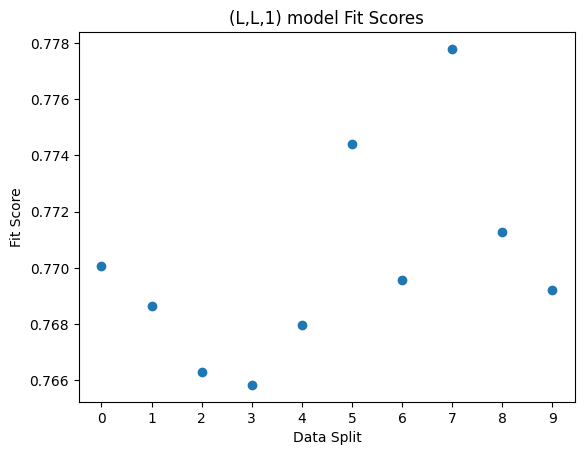

In [20]:
fits = []
for idx, mdl in enumerate(mdls):
    tmp_fit = 1 - eng.frobll1res(lwn_tns[idx], mdl) / eng.frob(lwn_tns[idx])
    fits.append(tmp_fit)
print(fits)
plt.scatter(range(10),fits)
plt.xlabel('Data Split')
plt.ylabel('Fit Score')
plt.xticks(range(10))
plt.title('(L,L,1) model Fit Scores')

## Recover 'Sources' & 'Mixing' matrices for each set

In [21]:
print(f"Number of models: {len(mdls)}")
sources = list()
mixes = list()
for idx, model in enumerate(mdls):
    tmp = ll1_tools.pack_ll1(model)
    mix = tmp[2]
    mixes.append(mix)
    src = ll1_tools.recover_sources(obs[idx], mix)
    sources.append(src)
print(f"Number of Source matrices: {len(sources)}")
print(f"Number of Mixing matrices: {len(mixes)}")

Number of models: 10
Number of Source matrices: 10
Number of Mixing matrices: 10


## Perform SVDs on transposed 'Sources' matrices as well as maximum angle between subspaces
(transpose so the left singular vectors correspond to the sources signal space)

In [22]:
sources_transposed = []
for src in sources:
    sources_transposed.append(src.T)
print(len(sources_transposed))

svds = []
for src in sources_transposed:
    svds.append(np.linalg.svd(src))
num_sets = len(sources)

angles_srcs = np.zeros((num_sets,num_sets))
angles_cols = np.zeros((num_sets,num_sets))
norm_of_diffs = np.zeros((num_sets,num_sets))
# cossims = np.zeros((num_sets,num_sets))
for i in range(num_sets):
    for j in range(num_sets):
        if i != j:
            angles_srcs[i,j] = eng.rad2deg(eng.subspace(sources_transposed[i], sources_transposed[j]))
            angles_cols[i,j] = eng.rad2deg(eng.subspace(svds[i][0], svds[j][0]))
            norm_of_diffs[i,j] = np.linalg.norm(sources_transposed[i] - sources_transposed[j])
            # cossims[i,j] = sklearn.metrics.pairwise.cosine_similarity(sources_transposed[i], sources_transposed[j])
            

10


## SVD analysis

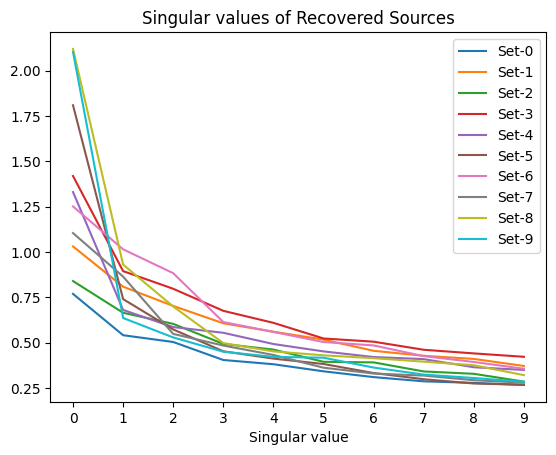

In [23]:
for i in range(len(svds)):
    plt.plot(svds[i][1][0:10], label=f"Set-{i}")
plt.xlabel('Singular value')
plt.xticks(range(len(svds)))
plt.title('Singular values of Recovered Sources')
plt.legend()

## Principal Angle Analysis

Text(0.5, 1.0, 'Largest Principal Angle Between Recovered Sources')

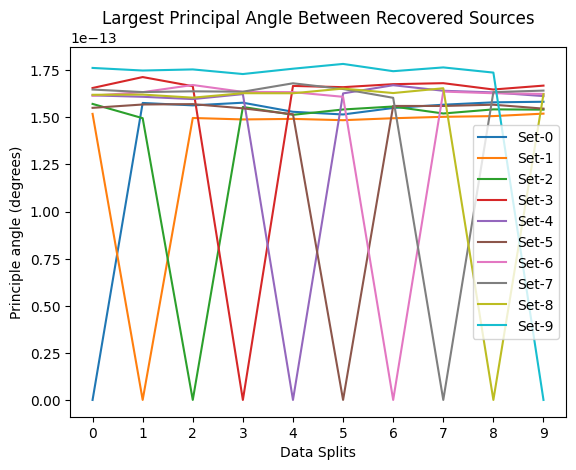

In [24]:
for i in range(angles_cols.shape[0]):
    plt.plot(angles_cols[i,:], label=f"Set-{i}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('Data Splits')
plt.ylabel('Principle angle (degrees)')
plt.title('Largest Principal Angle Between Recovered Sources')

## Norm of the Difference of Recovered Sources Analysis

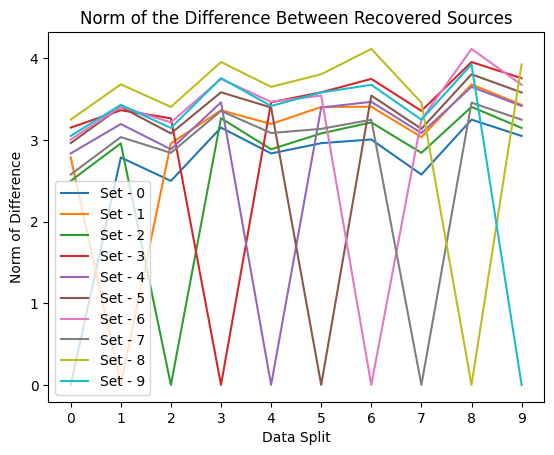

In [25]:
for i in range(norm_of_diffs.shape[0]):
    plt.plot(norm_of_diffs[i,:], label=f"Set - {i}")

plt.xlabel('Data Split')
plt.ylabel('Norm of Difference')
plt.xticks(range(10))
plt.title('Norm of the Difference Between Recovered Sources')
plt.legend()